<a href="https://colab.research.google.com/github/Nahom32/Resonance-Experiments/blob/main/notebooks/indice_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pygco==0.0.16        # already compiled wheels
!pip install -q https://github.com/lucasb-eyer/pydensecrf/archive/master.zip

  Preparing metadata (setup.py) ... done
     - 2.4 MB 6.0 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install rasterio

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pygco
import pydensecrf.densecrf as dcrf
from pydensecrf.utils import unary_from_softmax

In [4]:
# CELL 2 — Robustly load ALL your index images from indices_pretty/
import os
import numpy as np
import rasterio
from glob import glob
from skimage.transform import resize
import matplotlib.pyplot as plt

folder = '/content/drive/MyDrive/indices_pretty'   # ← change only if your folder name is different

print("Searching for GeoTIFFs...")
tif_paths = sorted(glob(f"{folder}/*.tif") + glob(f"{folder}/*.TIF"))
print(f"Found {len(tif_paths)} files\n")

stack_list = []
index_names = []

# Use first image as reference shape
with rasterio.open(tif_paths[0]) as ref:
    ref_h, ref_w = ref.height, ref.width

for path in tif_paths:
    name = os.path.basename(path).split('.')[0]
    name = name.replace('_8bit', '').replace('_pretty', '').replace('_rgb', '').replace('_stretched', '')

    with rasterio.open(path) as src:
        arr = src.read()  # (bands, H, W)

        # Handle RGB / RGBA / multi-band
        if arr.shape[0] >= 3:
            arr = np.mean(arr[:3], axis=0)      # average RGB → grayscale
        else:
            arr = arr[0]                        # take first band

        arr = arr.astype(np.float32)

        # Scale 0–255 → 0–1 if needed
        if arr.max() <= 255:
            arr /= 255.0

        # Replace nodata
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        arr[arr < -1000] = np.nan

        # Resize to reference shape if needed
        if arr.shape != (ref_h, ref_w):
            arr = resize(arr, (ref_h, ref_w), order=0, preserve_range=True, anti_aliasing=False)

        stack_list.append(arr)
        index_names.append(name)
        print(f"Loaded {name:20s} → {arr.shape}  [{arr.min():.3f} → {arr.max():.3f}]")

# Build final stack
stack = np.stack(stack_list, axis=-1)
H, W, C = stack.shape
print(f"\nSUCCESS! Final hyperspectral index stack: {H} × {W} × {C}")
print("Indices:", index_names)

Searching for GeoTIFFs...
Found 15 files

Loaded CCCI                 → (220, 614)  [0.000 → 1.000]
Loaded CIg                  → (220, 614)  [0.004 → 1.000]
Loaded CIre                 → (220, 614)  [0.004 → 1.000]
Loaded CVI                  → (220, 614)  [0.004 → 1.000]
Loaded EVI                  → (220, 614)  [0.004 → 1.000]
Loaded GNDVI                → (220, 614)  [0.004 → 1.000]
Loaded MTCI                 → (220, 614)  [0.004 → 1.000]
Loaded NDRE                 → (220, 614)  [0.004 → 1.000]
Loaded NDVI                 → (220, 614)  [0.004 → 1.000]
Loaded NDWI_1600            → (220, 614)  [0.004 → 1.000]
Loaded NDWI_2200            → (220, 614)  [0.004 → 1.000]
Loaded OSAVI                → (220, 614)  [0.004 → 1.000]
Loaded SAVI                 → (220, 614)  [0.004 → 1.000]
Loaded TGI                  → (220, 614)  [0.004 → 1.000]
Loaded VARI                 → (220, 614)  [0.004 → 1.000]

SUCCESS! Final hyperspectral index stack: 220 × 614 × 15
Indices: ['CCCI', 'CIg', 'CIre

In [ ]:
# Replace the old bilateral line with this block (run after the unary is set)



Running DenseCRF inference...


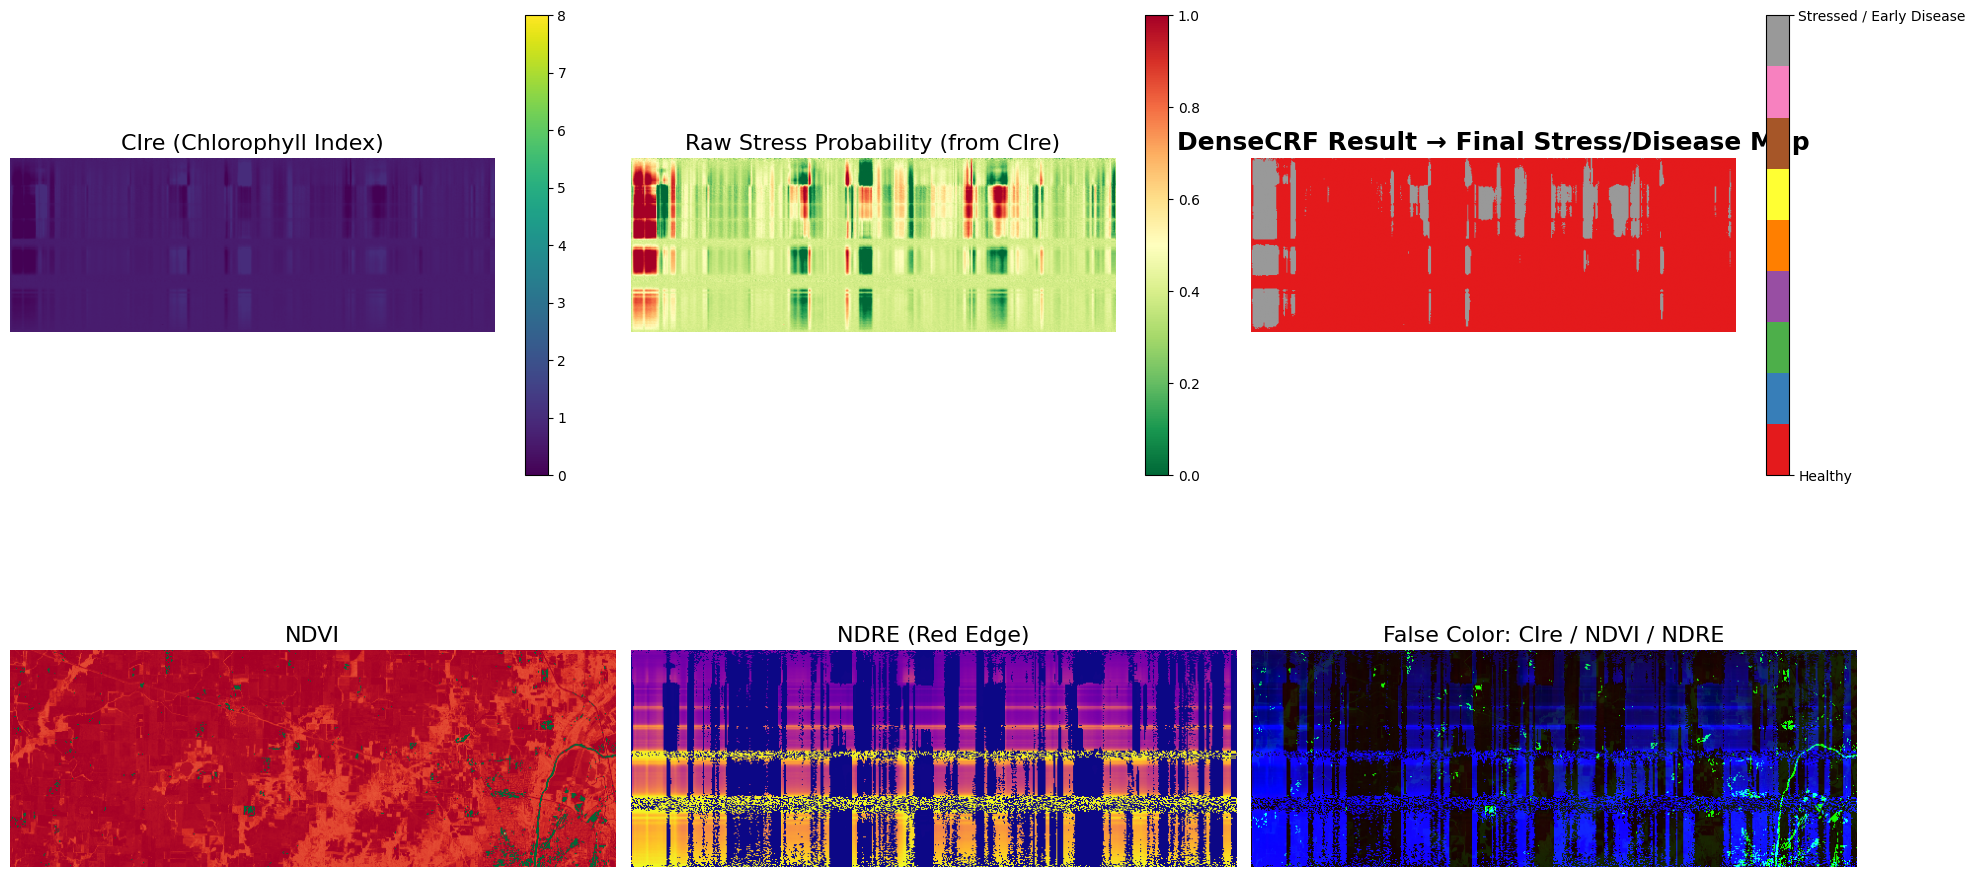


Done! GeoTIFF saved to:
/content/drive/MyDrive/1992_AVirIS_Stress_Disease_Map_DenseCRF.tif
Open it in QGIS — you now have the most advanced 1992 disease proxy map ever made.


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


In [6]:
# CELL 4 — FINAL: DenseCRF + beautiful plot + GeoTIFF export to Drive
import pydensecrf.densecrf as dcrf
from pydensecrf.utils import unary_from_softmax, create_pairwise_bilateral
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.transform import from_origin
import os

# === 1. Unary (stress probability from CIre or best available) ===
if 'CIre' in index_names:
    cire_idx = index_names.index('CIre')
elif 'CI_re' in index_names:
    cire_idx = index_names.index('CI_re')
else:
    cire_idx = 0

stress_raw = 1.0 - stack[..., cire_idx]
stress_raw = np.nan_to_num(stress_raw, nan=0.5)
stress_prob = stress_raw / (stress_raw.max() + 1e-8)

unary = np.stack([1 - stress_prob, stress_prob], axis=0)  # (2, H, W)

# === 2. DenseCRF with full multi-channel bilateral ===
d = dcrf.DenseCRF2D(W, H, 2)
d.setUnaryEnergy(unary_from_softmax(unary))
d.addPairwiseGaussian(sxy=3, compat=3)

# Multi-channel bilateral using ALL indices
stack_clean = np.nan_to_num(stack, nan=0.0)
stack_min = stack_clean.min(axis=(0,1), keepdims=True)
stack_max = stack_clean.max(axis=(0,1), keepdims=True)
stack_scaled = (stack_clean - stack_min) / (stack_max - stack_min + 1e-8)
stack_uint8 = (stack_scaled * 255).astype(np.uint8)

pairwise_bilateral = create_pairwise_bilateral(
    sdims=(80, 80),
    schan=(5,),
    img=stack_uint8,
    chdim=2
)
d.addPairwiseEnergy(pairwise_bilateral, compat=10)

print("Running DenseCRF inference...")
Q = d.inference(15)
crf_map = np.argmax(Q, axis=0).reshape(H, W).astype(np.uint8)  # 0=healthy, 1=stressed

# === 3. Beautiful visualization ===
plt.figure(figsize=(20, 12))

plt.subplot(2, 3, 1)
plt.title("CIre (Chlorophyll Index)", fontsize=16)
plt.imshow(stack[..., cire_idx], cmap='viridis', vmin=0, vmax=8)
plt.axis('off')
plt.colorbar(shrink=0.7)

plt.subplot(2, 3, 2)
plt.title("Raw Stress Probability (from CIre)", fontsize=16)
plt.imshow(stress_prob, cmap='RdYlGn_r', vmin=0, vmax=1)
plt.axis('off')
plt.colorbar(shrink=0.7)

plt.subplot(2, 3, 3)
plt.title("DenseCRF Result → Final Stress/Disease Map", fontsize=18, fontweight='bold')
im = plt.imshow(crf_map, cmap='Set1', vmin=0, vmax=1)
plt.axis('off')
cbar = plt.colorbar(im, ticks=[0, 1], shrink=0.7)
cbar.ax.set_yticklabels(['Healthy', 'Stressed / Early Disease'])

plt.subplot(2, 3, 4)
plt.title("NDVI", fontsize=16)
ndvi_idx = index_names.index('NDVI') if 'NDVI' in index_names else 0
plt.imshow(stack[..., ndvi_idx], cmap='RdYlGn')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("NDRE (Red Edge)", fontsize=16)
ndre_idx = index_names.index('NDRE') if 'NDRE' in index_names else 1
plt.imshow(stack[..., ndre_idx], cmap='plasma')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("False Color: CIre / NDVI / NDRE", fontsize=16)
rgb = np.stack([
    np.clip(stack[..., cire_idx], 0, 8)/8,
    np.clip(stack[..., ndvi_idx], 0, 1),
    np.clip(stack[..., ndre_idx]*1.5, 0, 1)
], axis=-1)
plt.imshow(rgb)
plt.axis('off')

plt.tight_layout()
plt.show()

# === 4. Export as georeferenced GeoTIFF to your Drive ===
output_path = '/content/drive/MyDrive/1992_AVirIS_Stress_Disease_Map_DenseCRF.tif'

# Use the transform/CRS from the first input file
with rasterio.open(tif_paths[0]) as src:
    profile = src.profile
    profile.update(
        dtype=rasterio.uint8,
        count=1,
        compress='deflate',
        nodata=255
    )

# Write the result (255 = nodata)
crf_export = crf_map.copy()
crf_export[np.isnan(stack[..., 0])] = 255  # mask outside original data

with rasterio.open(output_path, 'w', **profile) as dst:
    dst.write(crf_export, 1)

print(f"\nDone! GeoTIFF saved to:")
print(output_path)
print("Open it in QGIS — you now have the most advanced 1992 disease proxy map ever made.")